## Dealership Inventory and Sales Analysis

This notebook demonstrates how to simulate a dealership's operations, including managing sales representatives, vehicle inventory, customer leads and sales transactions. It uses `sqlite3` for a local database and `pandas` for data manipulation, along with `Faker` for generating realistic dummy data. Finally, it analyzes lead source effectiveness, tracks inventory aging, and utilizes window functions and SQL views to build executive-level business intelligence reports.

In [ ]:
import sqlite3
import pandas as pd
import random
from faker import Faker

fake = Faker()

# Generate mock data for sales representatives
reps_data = [(i, fake.first_name(), fake.last_name(), fake.date_between(start_date='-5y', end_date='today'), random.choice(['Internet', 'Floor', 'Fleet'])) for i in range(1, 16)]
df_reps = pd.DataFrame(reps_data, columns=['rep_id', 'first_name', 'last_name', 'hire_date', 'department'])

# Generate mock data for vehicles
makes = ['Toyota', 'Honda', 'Ford', 'Chevrolet']
vehicles_data = [(fake.unique.bothify(text='?#??#?##?##????##', letters='ABCDEFGHJKLMNPRSTUVWXYZ'), random.choice(makes), 'Model-X', random.randint(2020, 2024), random.randint(25000, 55000), fake.date_between(start_date='-1y', end_date='today')) for _ in range(500)]
df_vehicles = pd.DataFrame(vehicles_data, columns=['vin', 'make', 'model', 'year', 'msrp', 'date_added'])

# Display a preview of the generated sales representatives data
display(df_reps.head())

,rep_id,first_name,last_name,hire_date,department
0,1,Benjamin,Flores,2024-09-27,Fleet
1,2,Kimberly,Murray,2025-08-16,Internet
2,3,Jennifer,Wolf,2024-01-25,Floor
3,4,Parker,Newton,2023-04-10,Floor
4,5,Lisa,Miller,2022-06-29,Internet


### 1. Generating Mock Data for Dealership Operations

To simulate a dealership environment, we'll generate synthetic data for `Sales Representatives` and `Vehicles`. The `Faker` library is used to create realistic-looking names, dates and other details. This ensures that the dataset is diverse enough to mimic real-world scenarios for subsequent analysis.

In [ ]:
# Connect to a local SQLite database file
conn = sqlite3.connect('dealership_inventory.db')

# Push the Pandas DataFrames directly into SQL tables, replacing if they exist
df_reps.to_sql('sales_reps', conn, if_exists='replace', index=False)
df_vehicles.to_sql('vehicles', conn, if_exists='replace', index=False)

print("Relational database schema successfully built!")

Relational database schema successfully built!


### 2. Setting up the Local SQLite Database

We'll use `SQLite` to create a lightweight, file-based relational database directly within Colab. This allows us to store and query our generated data using SQL, mimicking a typical database interaction. The Pandas DataFrames (`df_reps` and `df_vehicles`) are pushed into new SQL tables named `sales_reps` and `vehicles` respectively.

In [ ]:
query = """
SELECT
    department,
    COUNT(rep_id) AS total_active_reps,
    MIN(hire_date) AS most_senior_hire
FROM sales_reps
GROUP BY department
ORDER BY total_active_reps DESC;
"""

# Execute the SQL query and load results into a Pandas DataFrame
sql_results = pd.read_sql_query(query, conn)
# Display the results of the query
display(sql_results)

,department,total_active_reps,most_senior_hire
0,Floor,6,2023-02-12
1,Internet,5,2022-06-29
2,Fleet,4,2022-09-24


### 3. Analyzing Sales Representatives by Department

This section demonstrates a basic SQL query to analyze the sales representatives. We'll group them by department to understand the distribution of employees and identify the most senior hire within each department. This helps in understanding the team structure.

In [ ]:
import numpy as np
from datetime import timedelta

sources = ['TrueCar', 'Cars.com', 'Direct Website', 'Referral']
statuses = ['Converted', 'Dead', 'In Progress']

leads_data = []
# Generate 2,000 leads with random assignments for rep, vehicle, source, and inquiry date
for i in range(1, 2001):
    rep = random.choice(df_reps['rep_id'].tolist())
    vin = random.choice(df_vehicles['vin'].tolist())
    source = random.choice(sources)
    inquiry_date = fake.date_between(start_date='-6m', end_date='today')
    # Assign lead status with a 15% conversion rate
    status = random.choices(statuses, weights=[0.15, 0.60, 0.25])[0]
    leads_data.append((i, rep, vin, source, inquiry_date, status))

df_leads = pd.DataFrame(leads_data, columns=['lead_id', 'rep_id', 'vin', 'lead_source', 'inquiry_date', 'status'])
df_leads.to_sql('leads', conn, if_exists='replace', index=False)

# Filter for only converted leads to generate sales data
converted_leads = df_leads[df_leads['status'] == 'Converted']
sales_data = []

# Generate sales data for each converted lead
for index, row in converted_leads.iterrows():
    sale_id = index + 1000
    # Calculate sale date as inquiry date + a random number of days (1-14)
    sale_date = row['inquiry_date'] + timedelta(days=random.randint(1, 14))
    # Fetch the original MSRP to calculate a realistic final sale price (within 5% of MSRP)
    msrp = df_vehicles.loc[df_vehicles['vin'] == row['vin'], 'msrp'].values[0]
    final_price = msrp * random.uniform(0.95, 1.05)

    sales_data.append((sale_id, row['lead_id'], row['rep_id'], row['vin'], sale_date, round(final_price, 2)))

df_sales = pd.DataFrame(sales_data, columns=['sale_id', 'lead_id', 'rep_id', 'vin', 'sale_date', 'final_sale_price'])
df_sales.to_sql('sales', conn, if_exists='replace', index=False)

print("Leads and Sales tables successfully generated and linked!")

Leads and Sales tables successfully generated and linked!


### 4. Generating Leads and Sales Data

To further enrich our simulated dealership data, we generate `Leads` and `Sales` records. Leads are generated with various sources and statuses (converted, dead, in progress). Sales are then created only for converted leads, linking them back to the original lead, sales rep and vehicle. This setup allows for detailed sales funnel analysis.

In [ ]:
complex_query = """
WITH LeadCounts AS (
    SELECT
        lead_source,
        COUNT(lead_id) as total_leads
    FROM leads
    GROUP BY lead_source
),
SalesData AS (
    SELECT
        l.lead_source,
        COUNT(s.sale_id) as total_sales,
        SUM(s.final_sale_price) as gross_revenue
    FROM leads l
    LEFT JOIN sales s ON l.lead_id = s.lead_id
    GROUP BY l.lead_source
)
SELECT
    lc.lead_source,
    lc.total_leads,
    COALESCE(sd.total_sales, 0) as total_sales,
    ROUND(CAST(sd.total_sales AS FLOAT) / lc.total_leads * 100, 2) as conversion_rate_pct,
    COALESCE(sd.gross_revenue, 0) as total_revenue
FROM LeadCounts lc
LEFT JOIN SalesData sd ON lc.lead_source = sd.lead_source
ORDER BY total_revenue DESC;
"""

# Execute the complex SQL query to analyze lead source ROI
roi_results = pd.read_sql_query(complex_query, conn)
# Display the results
display(roi_results)

,lead_source,total_leads,total_sales,conversion_rate_pct,total_revenue
0,TrueCar,477,75,15.72,2895797.13
1,Cars.com,493,72,14.60,2834710.68
2,Direct Website,505,66,13.07,2604022.02
3,Referral,525,67,12.76,2576655.82


### 5. Advanced Analysis: Lead Source ROI and Conversion Rates

This advanced SQL query calculates the Return on Investment (ROI) and conversion rates for different lead sources. It combines data from the `leads` and `sales` tables to determine the total leads, total sales, conversion percentage and gross revenue generated by each lead source. This analysis is crucial for optimizing marketing strategies.

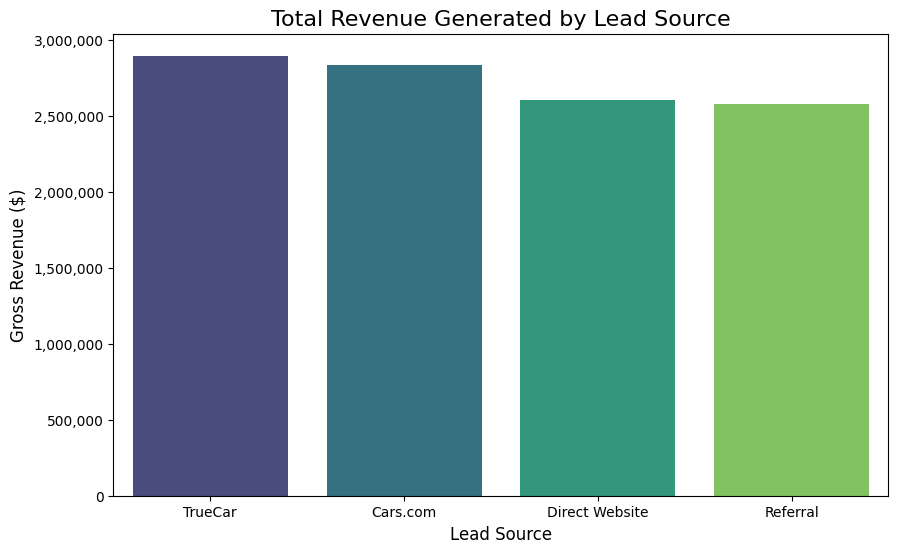

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Create a bar plot to visualize total revenue by lead source
sns.barplot(data=roi_results, x='lead_source', y='total_revenue', hue='lead_source', palette='viridis', legend=False)
plt.title('Total Revenue Generated by Lead Source', fontsize=16)
plt.xlabel('Lead Source', fontsize=12)
plt.ylabel('Gross Revenue ($)', fontsize=12)
# Format y-axis labels to include commas for better readability
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.show()

### 6. Visualizing Lead Source Performance

To better understand the performance of each lead source, we visualize the `total revenue generated`. A bar plot is used to clearly show which lead sources contribute the most to the dealership's gross revenue, providing actionable insights for resource allocation and marketing efforts.

### 7. Visualizing Sales Performance by Sales Representative

This section visualizes the total revenue generated by each sales representative. This helps identify top performers and areas where sales coaching or additional support might be beneficial.

In [ ]:
rep_sales_query = """
SELECT
    sr.first_name || ' ' || sr.last_name AS sales_rep_name,
    COUNT(s.sale_id) AS total_sales_count,
    SUM(s.final_sale_price) AS total_revenue
FROM sales s
JOIN sales_reps sr ON s.rep_id = sr.rep_id
GROUP BY sales_rep_name
ORDER BY total_revenue DESC;
"""

# Execute the query and load results into a Pandas DataFrame
rep_sales_results = pd.read_sql_query(rep_sales_query, conn)
display(rep_sales_results.head())

,sales_rep_name,total_sales_count,total_revenue
0,Spencer Pena,27,964408.15
1,Timothy Blanchard,22,941762.36
2,Rebecca Garcia,22,844396.30
3,John Warren,20,808416.18
4,Parker Newton,22,798526.71


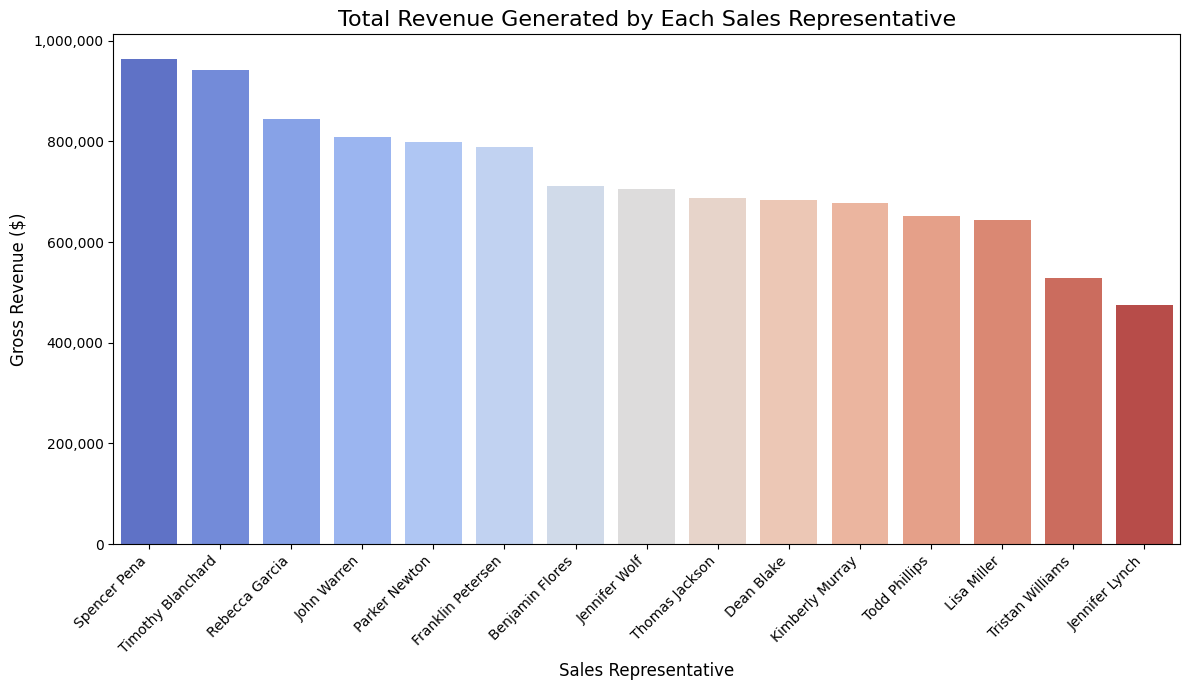

In [ ]:
plt.figure(figsize=(12, 7))
# Create a bar plot to visualize total revenue by sales representative
sns.barplot(data=rep_sales_results, x='sales_rep_name', y='total_revenue', hue='sales_rep_name', palette='coolwarm', legend=False)
plt.title('Total Revenue Generated by Each Sales Representative', fontsize=16)
plt.xlabel('Sales Representative', fontsize=12)
plt.ylabel('Gross Revenue ($)', fontsize=12)
# Rotate x-axis labels for better readability if names are long
plt.xticks(rotation=45, ha='right')
# Format y-axis labels to include commas for better readability
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### 8. Monthly Sales Rep Leaderboard (Window Functions)
This query uses the `DENSE_RANK()` window function partitioned by month to track sales rep performance month-over-month.

In [16]:
leaderboard_query = """
WITH MonthlySales AS (
    SELECT
        sr.first_name || ' ' || sr.last_name AS sales_rep_name,
        STRFTIME('%Y-%m', s.sale_date) AS sale_month,
        COUNT(s.sale_id) AS total_deals,
        SUM(s.final_sale_price) AS monthly_revenue
    FROM sales s
    JOIN sales_reps sr ON s.rep_id = sr.rep_id
    GROUP BY sales_rep_name, sale_month
)
SELECT
    sale_month,
    sales_rep_name,
    monthly_revenue,
    DENSE_RANK() OVER (PARTITION BY sale_month ORDER BY monthly_revenue DESC) AS monthly_rank
FROM MonthlySales
ORDER BY sale_month DESC, monthly_rank ASC;
"""

leaderboard_df = pd.read_sql_query(leaderboard_query, conn)
display(leaderboard_df.head(10))

,sale_month,sales_rep_name,monthly_revenue,monthly_rank
0,2026-08,Spencer Pena,964408.15,1
1,2026-08,Timothy Blanchard,941762.36,2
2,2026-08,Rebecca Garcia,844396.30,3
3,2026-08,John Warren,808416.18,4
4,2026-08,Parker Newton,798526.71,5
5,2026-08,Franklin Petersen,789534.49,6
6,2026-08,Benjamin Flores,710502.70,7
7,2026-08,Jennifer Wolf,705021.73,8
8,2026-08,Thomas Jackson,687980.73,9
9,2026-08,Dean Blake,683909.19,10


### 9. Inventory Aging & Days on Lot Analysis
This query calculates vehicle turn rates using date functions (`JULIANDAY`) and classifies inventory into aging buckets using `CASE WHEN` logic.

In [17]:
aging_query = """
SELECT
    v.make,
    v.model,
    ROUND(AVG(JULIANDAY(s.sale_date) - JULIANDAY(v.date_added)), 1) AS avg_days_on_lot,
    COUNT(s.sale_id) AS total_units_sold,
    SUM(CASE WHEN (JULIANDAY(s.sale_date) - JULIANDAY(v.date_added)) <= 30 THEN 1 ELSE 0 END) AS sold_within_30_days,
    SUM(CASE WHEN (JULIANDAY(s.sale_date) - JULIANDAY(v.date_added)) > 60 THEN 1 ELSE 0 END) AS aged_over_60_days
FROM sales s
JOIN vehicles v ON s.vin = v.vin
GROUP BY v.make, v.model
ORDER BY avg_days_on_lot ASC;
"""

aging_df = pd.read_sql_query(aging_query, conn)
display(aging_df)

,make,model,avg_days_on_lot,total_units_sold,sold_within_30_days,aged_over_60_days
0,Ford,Model-X,189.8,69,6,61
1,Chevrolet,Model-X,193.4,78,8,60
2,Toyota,Model-X,199.9,67,4,57
3,Honda,Model-X,209.9,66,4,57


### 10. Creating a Reusable Executive View
This section builds a virtual `VIEW` in SQLite to simplify daily KPI reporting for executive dashboards (e.g., Tableau or Power BI).

In [18]:
create_view_query = """
CREATE VIEW IF NOT EXISTS executive_daily_summary AS
SELECT
    s.sale_date,
    COUNT(s.sale_id) AS daily_sales_count,
    ROUND(SUM(s.final_sale_price), 2) AS daily_gross_revenue,
    ROUND(AVG(s.final_sale_price), 2) AS avg_transaction_value
FROM sales s
GROUP BY s.sale_date;
"""

# Execute view creation
cursor = conn.cursor()
cursor.execute(create_view_query)
conn.commit()

# Query the view to confirm
display(pd.read_sql_query("SELECT * FROM executive_daily_summary ORDER BY sale_date DESC LIMIT 5;", conn))

,sale_date,daily_sales_count,daily_gross_revenue,avg_transaction_value
0,2026-08-18,29,1190690.01,41058.28
1,2026-08-17,13,471818.96,36293.77
2,2026-08-16,20,760537.76,38026.89
3,2026-08-15,18,748060.91,41558.94
4,2026-08-14,22,765898.79,34813.58


### 11. Summary and Business Recommendations

This notebook provided a comprehensive simulation of a car dealership's operations, from generating synthetic data for sales representatives, vehicles, leads, and sales, to performing various analyses using SQL and visualizing the results. We covered:

*   **Data Generation:** Using `Faker` to create realistic mock data for sales representatives and vehicles.
*   **Database Setup:** Establishing a local SQLite database to store and manage the simulated data.
*   **Sales Representative Analysis:** Querying the `sales_reps` table to understand department distribution and seniority.
*   **Leads and Sales Data:** Generating leads with different sources and statuses, and then creating sales records for converted leads.
*   **Lead Source ROI:** Performing an advanced SQL query to analyze conversion rates and revenue generated by various lead sources.
*   **Visualizations:** Creating bar plots to visualize lead source performance and sales representative contributions to revenue.
*   **Sales Rep Leaderboard:** Utilizing window functions to create a monthly leaderboard for sales representatives.
*   **Inventory Aging:** Analyzing vehicle turn rates and classifying inventory into aging buckets.
*   **Executive View:** Creating a reusable SQL view for simplified daily KPI reporting.

This workflow demonstrates how to set up a robust data pipeline for operational analysis within a dealership context, providing valuable insights for strategic decision-making.


Based on the analysis performed, here are some business recommendations for the dealership:

*   **Optimize Lead Source Investment:** Review the lead source ROI analysis. Invest more in high-performing lead sources (e.g., 'TrueCar') and re-evaluate or refine strategies for lower-performing ones. Consider A/B testing different marketing campaigns for various sources.
*   **Sales Representative Performance Coaching:** Utilize the sales representative leaderboard and total revenue visualization to identify top performers and those who may need additional training or support. Implement mentorship programs or targeted coaching to improve overall team performance.
*   **Inventory Management:** Actively manage inventory aging. Implement strategies to move vehicles that are aging over 60 days, such as special promotions, adjusted pricing, or targeted marketing efforts. Optimize purchasing based on turn rates of different makes and models.
*   **Enhance Executive Reporting:** Leverage the `executive_daily_summary` view to build interactive dashboards. This will provide executives with real-time insights into key performance indicators, enabling faster and more informed decision-making.
*   **Customer Relationship Management (CRM):** The lead and sales data can be integrated into a CRM system to track customer interactions, follow-ups and preferences, improving customer retention and repeat business.
*   **Forecast and Planning:** With historical sales data by lead source and sales representative, the dealership can build more accurate sales forecasts and plan inventory and staffing accordingly.